# Crawling & Analisis Data Polutan Udara di Kabupaten Gresik

**Nama:** Ahmad Syahrul Farihin

**NIM:** 240411100031

**Mata Kuliah:** Pengantar Sains Data (PSD) - B

Notebook ini membahas enam jenis polutan udara (CO, NO2, HCHO, O3, SO2, CH4) di wilayah Kabupaten Gresik menggunakan data satelit Sentinel-5P. Pembahasan dibatasi hingga tahap **Business Understanding** dan **Data Understanding**, ditutup dengan grafik time series.

## 1. Business Understanding

### 1.1 Latar Belakang

Kabupaten Gresik merupakan salah satu kawasan industri terbesar di Jawa Timur, dengan keberadaan industri semen, pupuk/petrokimia, pengolahan logam, pengolahan minyak nabati, kawasan industri terintegrasi (JIIPE), serta jalur transportasi Pantura yang padat. Kombinasi aktivitas tersebut berpotensi menjadi sumber berbagai gas pencemar udara. Pemantauan kualitas udara di wilayah semacam ini penting dilakukan karena sumber pencemarannya bisa berasal dari beberapa sektor sekaligus (industri, transportasi, maupun aktivitas lain), yang proporsinya bisa berbeda dari wilayah lain.

### 1.2 Tujuan

- Mengumpulkan data enam polutan udara (CO, NO2, HCHO, O3, SO2, CH4) di wilayah Gresik selama periode minimal satu tahun sebelum 31 Agustus 2026.
- Mengamati perubahan konsentrasi tiap polutan dari waktu ke waktu melalui grafik time series.
- Mengidentifikasi kemungkinan sumber emisi masing-masing polutan berdasarkan karakteristik wilayah.
- Melakukan Data Understanding: memeriksa struktur data, missing value, dan outlier/data aneh.

### 1.3 Manfaat

Hasil analisis ini diharapkan memberi gambaran awal kondisi kualitas udara di Kabupaten Gresik serta pola konsentrasi tiap polutan sepanjang waktu, sekaligus menjadi landasan bagi tahap preprocessing dan pemodelan pada pertemuan berikutnya.

### 1.4 Penjelasan dan Kemungkinan Sumber Tiap Polutan

| Polutan | Apa Itu? | Kemungkinan Sumber |
|---|---|---|
| **CO** (Karbon Monoksida) | Gas tidak berwarna dan tidak berbau, terbentuk dari pembakaran bahan bakar yang tidak sempurna. Berikatan dengan hemoglobin lebih kuat daripada oksigen sehingga berbahaya bagi pernapasan. | Emisi kendaraan bermotor, pembakaran biomassa/lahan, aktivitas industri dengan proses pembakaran |
| **NO2** (Nitrogen Dioksida) | Gas hasil pembakaran suhu tinggi, berperan dalam pembentukan hujan asam dan ozon permukaan. | Emisi kendaraan bermotor, pembangkit listrik, industri (semen, petrokimia) |
| **HCHO** (Formaldehida) | Senyawa organik volatil (VOC), sering dipakai sebagai indikator tidak langsung emisi VOC di atmosfer. | Industri kimia/petrokimia, kebakaran biomassa, emisi kendaraan, oksidasi VOC dari vegetasi |
| **O3** (Ozon Troposferik) | Bukan gas yang diemisikan langsung, melainkan polutan sekunder hasil reaksi fotokimia NOx dan VOC dengan bantuan sinar matahari. | Reaksi emisi kendaraan/industri (NOx, VOC) dengan sinar matahari |
| **SO2** (Sulfur Dioksida) | Gas hasil pembakaran bahan bakar yang mengandung sulfur. | Pembangkit listrik berbahan bakar batu bara, industri semen dan peleburan logam |
| **CH4** (Metana) | Gas rumah kaca dengan efek pemanasan jauh lebih kuat dari CO2. | Lahan persawahan, TPA sampah, peternakan, kebocoran gas alam, industri migas |

### 1.5 Deskripsi Data

- **Sumber data:** Sentinel-5P TROPOMI (koleksi `SENTINEL_5P_L2`), diakses lewat `openeo` pada Copernicus Data Space Ecosystem.
- **Cakupan wilayah:** Kabupaten Gresik, dibatasi memakai polygon GeoJSON yang digambar lewat geojson.io.
- **Periode target:** minimal satu tahun hingga 31 Agustus 2026.
- **Satuan:** CO, NO2, HCHO, O3, dan SO2 dilaporkan sebagai kolom vertikal dalam **mol/m²**, sedangkan **CH4 dilaporkan dalam ppb** (*dry-air column-averaged mixing ratio*) - bukan mol/m² - sehingga skalanya jauh lebih besar (ribuan) dan tidak bisa dibandingkan langsung dengan polutan lain tanpa normalisasi.
- **Keluaran:** satu berkas `.csv` berisi kolom `date` serta enam kolom polutan.

## 2. Data Understanding

### 2.1 Wilayah Kajian (Area of Interest)

Batas wilayah kajian dibuat sebagai polygon GeoJSON melalui geojson.io, mencakup wilayah Kabupaten Gresik. Polygon ini kemudian dibaca ulang di Python untuk dihitung bounding box-nya, yang menjadi acuan spasial pada saat data ditarik dari server Copernicus.

In [48]:
!pip install openeo netCDF4 numpy pandas matplotlib -q

In [49]:
import json
import openeo
import netCDF4
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

**Penjelasan kode:** Seluruh pustaka yang dipakai sepanjang notebook (untuk membaca/menulis GeoJSON, mengambil data satelit, membaca berkas NetCDF, mengolah tabel, dan membuat grafik) diimpor sekaligus di sini agar tidak berulang-ulang di tiap bagian.

In [ ]:
aoi_gresik = {
    "type": "Polygon",
    "coordinates": [[
        [112.55788600733189, -7.1497735],
        [112.6117995, -7.1232868],
        [112.6562032, -7.1497735],
        [112.6675169, -7.1838502],
        [112.6562032, -7.218131475385974],
        [112.605102, -7.2404483],
        [112.55788600733189, -7.218131475385974],
        [112.55788600733189, -7.1497735],
    ]]
}

with open("aoi_gresik.geojson", "w") as f:
    json.dump({"type": "FeatureCollection",
               "features": [{"type": "Feature", "properties": {}, "geometry": aoi_gresik}]}, f)

titik_polygon = aoi_gresik["coordinates"][0]
lon_list = [p[0] for p in titik_polygon]
lat_list = [p[1] for p in titik_polygon]

bbox = {
    "west": min(lon_list), "south": min(lat_list),
    "east": max(lon_list), "north": max(lat_list)
}
print("Bounding box wilayah Gresik:", bbox)

Bounding box wilayah Gresik: {'west': 112.55788600733189, 'south': -7.2404483, 'east': 112.6675169, 'north': -7.1232868}


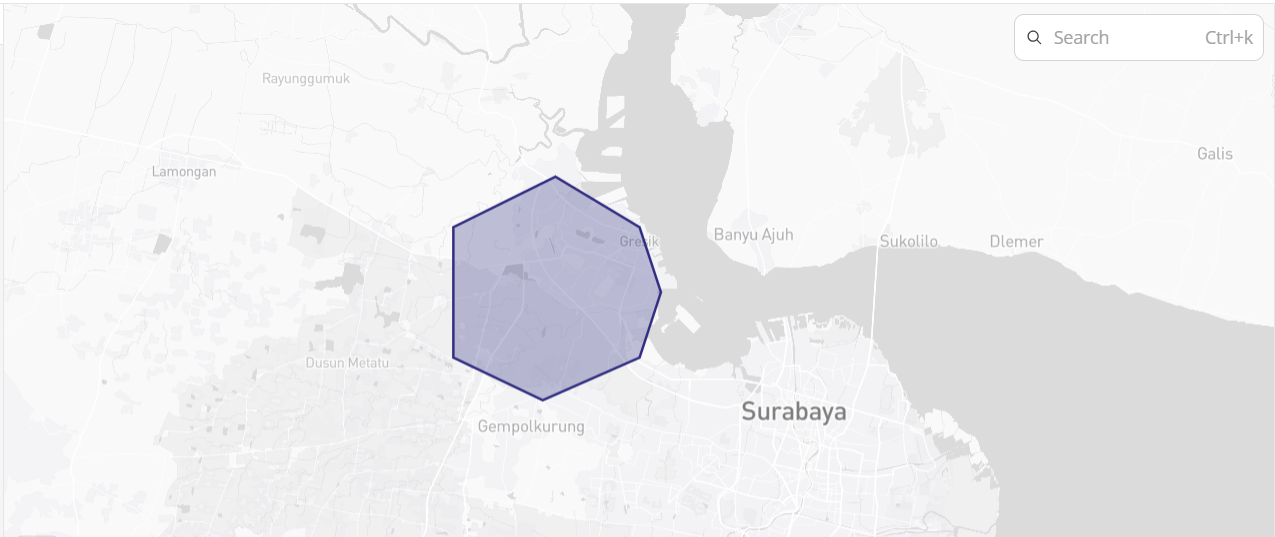

Keterangan: `aoi_gresik` menyimpan bentuk polygon wilayah kajian, sedangkan `bbox` adalah kotak pembatas terluarnya yang dipakai sebagai parameter `spatial_extent` saat memanggil data ke server.

### 2.2 Pengumpulan Data (Crawling)

Selanjutnya dibuat koneksi ke Copernicus Data Space Ecosystem (library pendukung sudah diinstal dan diimpor di bagian awal notebook).

In [ ]:
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

**Penjelasan kode:** `openeo.connect(...)` membuka koneksi ke server Copernicus Data Space Ecosystem, sedangkan `.authenticate_oidc()` menjalankan proses login (akan muncul tautan autentikasi yang perlu dibuka dan di-login memakai akun Copernicus). Objek `connection` inilah yang dipakai pada semua permintaan data selanjutnya.


Perlu diperhatikan bahwa satu permintaan `load_collection` pada koleksi `SENTINEL_5P_L2` hanya dapat memuat **satu band/polutan**. Oleh sebab itu, dibuat dua fungsi bantu: satu untuk mengambil dan mengunduh data satu polutan, satu lagi untuk membaca hasil unduhan tersebut dan mengubahnya menjadi tabel harian. Kedua fungsi ini dipanggil berulang untuk keenam polutan.

In [ ]:
daftar_polutan = ["CO", "NO2", "HCHO", "O3", "SO2", "CH4"]

tanggal_mulai = "2025-08-31"
tanggal_akhir = "2026-09-01"


def ambil_dan_unduh(kode_polutan):
    # Menarik satu jenis polutan dari SENTINEL_5P_L2 dan menyimpannya sebagai NetCDF.
    kubus = connection.load_collection(
        "SENTINEL_5P_L2",
        temporal_extent=[tanggal_mulai, tanggal_akhir],
        spatial_extent=bbox,
        bands=[kode_polutan],
    )
    kubus_harian = kubus.aggregate_temporal_period(reducer="mean", period="day")

    nama_file = f"{kode_polutan}_Gresik.nc"
    kubus_harian.execute_batch(title=f"Data {kode_polutan} Gresik", outputfile=nama_file)
    return nama_file

**Penjelasan kode:** `ambil_dan_unduh()` menyusun permintaan data ke koleksi `SENTINEL_5P_L2` untuk satu polutan (`kode_polutan`), dibatasi rentang waktu (`tanggal_mulai`–`tanggal_akhir`) dan wilayah (`bbox`). `aggregate_temporal_period(reducer="mean", period="day")` meringkas data menjadi satu nilai per hari, lalu `execute_batch(...)` menjalankan proses tersebut di server dan mengunduh hasilnya sebagai berkas NetCDF (`.nc`).

In [ ]:
def rangkum_harian(kode_polutan, nama_file):
    #Membaca NetCDF hasil unduhan, lalu meringkas nilai per hari.

    ds = netCDF4.Dataset(nama_file)

    array_nilai = ds.variables[kode_polutan][:]
    waktu = ds.variables["t"]

    daftar_tanggal = netCDF4.num2date(
        waktu[:],
        units=waktu.units
    )

    rata_harian = []

    for i in range(len(daftar_tanggal)):
        nilai = np.ma.mean(array_nilai[i])

        # Jika nilainya masked, ubah menjadi NaN
        if np.ma.is_masked(nilai):
            rata_harian.append(np.nan)
        else:
            rata_harian.append(float(nilai))

    return pd.DataFrame({
        "date": [t.strftime("%Y-%m-%d") for t in daftar_tanggal],
        kode_polutan: rata_harian
    })

**Penjelasan kode:** `rangkum_harian()` membuka berkas NetCDF hasil `ambil_dan_unduh()`, mengambil array nilai polutan (berdimensi waktu × baris grid × kolom grid) beserta informasi waktunya, lalu mengonversi waktu tersebut menjadi tanggal dengan `netCDF4.num2date()`. Untuk tiap hari, seluruh nilai pada grid dirata-ratakan memakai `np.ma.mean()`, yang otomatis mengabaikan piksel bernilai kosong/masked (misalnya akibat tutupan awan). Hasil akhirnya berupa tabel dua kolom: tanggal dan nilai rata-rata polutan.

Selanjutnya, kedua fungsi tersebut dipanggil untuk tiap polutan, dan hasilnya digabungkan menjadi satu tabel berdasarkan kolom `date`.

In [ ]:
tabel_gabungan = None

for kode in daftar_polutan:
    print(f"Memproses polutan {kode} ...")
    file_nc = ambil_dan_unduh(kode)
    tabel_polutan = rangkum_harian(kode, file_nc)

    if tabel_gabungan is None:
        tabel_gabungan = tabel_polutan
    else:
        tabel_gabungan = tabel_gabungan.merge(tabel_polutan, on="date", how="outer")

tabel_gabungan["date"] = pd.to_datetime(tabel_gabungan["date"])
tabel_gabungan = tabel_gabungan.sort_values("date").reset_index(drop=True)
tabel_gabungan.to_csv("polutan_gresik_timeseries.csv", index=False, na_rep="")

print("\nData berhasil disimpan!")
print("Tanggal pertama :", tabel_gabungan["date"].min().date())
print("Tanggal terakhir:", tabel_gabungan["date"].max().date())
print("Jumlah baris    :", len(tabel_gabungan))

Memproses polutan CO ...
0:00:00 Job 'j-2609050712114a73a494e620d974358e': send 'start'
0:00:04 Job 'j-2609050712114a73a494e620d974358e': queued (progress 0%)
0:00:10 Job 'j-2609050712114a73a494e620d974358e': queued (progress 0%)
0:00:17 Job 'j-2609050712114a73a494e620d974358e': queued (progress 0%)
0:00:25 Job 'j-2609050712114a73a494e620d974358e': queued (progress 0%)
0:00:35 Job 'j-2609050712114a73a494e620d974358e': queued (progress 0%)
0:00:47 Job 'j-2609050712114a73a494e620d974358e': queued (progress 0%)
0:01:03 Job 'j-2609050712114a73a494e620d974358e': queued (progress 0%)
0:01:22 Job 'j-2609050712114a73a494e620d974358e': running (progress N/A)
0:01:46 Job 'j-2609050712114a73a494e620d974358e': running (progress N/A)
0:02:17 Job 'j-2609050712114a73a494e620d974358e': running (progress N/A)
0:02:54 Job 'j-2609050712114a73a494e620d974358e': running (progress N/A)
0:03:41 Job 'j-2609050712114a73a494e620d974358e': running (progress N/A)
0:04:40 Job 'j-2609050712114a73a494e620d974358e': 

**Penjelasan kode:** Perulangan `for kode in daftar_polutan` memanggil `ambil_dan_unduh()` dan `rangkum_harian()` untuk tiap polutan secara berurutan, lalu hasil tiap polutan digabungkan ke `tabel_gabungan` berdasarkan kolom `date` memakai `merge(..., how="outer")` — opsi `outer` dipakai agar tanggal yang datanya kosong pada salah satu polutan tetap tersimpan sebagai `NaN`, bukan ikut terhapus dari tabel. Tabel akhir kemudian diurutkan berdasarkan tanggal dan disimpan ke `polutan_gresik_timeseries.csv`.

### 2.3 Struktur dan Isi Data

Mulai bagian ini, data dibaca kembali dari berkas CSV yang sudah tersimpan, sehingga proses eksplorasi berikutnya tidak perlu mengulang crawling dari awal.

In [ ]:
df = pd.read_csv("polutan_gresik_timeseries.csv", parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)

print("Jumlah baris :", len(df))
print("Kolom        :", list(df.columns))
print("Rentang tgl  :", df["date"].min().date(), "s.d.", df["date"].max().date())
print()
df.info()

Jumlah baris : 366
Kolom        : ['date', 'CO', 'NO2', 'HCHO', 'O3', 'SO2', 'CH4']
Rentang tgl  : 2025-08-31 s.d. 2026-08-31

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    366 non-null    datetime64[ns]
 1   CO      269 non-null    float64       
 2   NO2     239 non-null    float64       
 3   HCHO    291 non-null    float64       
 4   O3      362 non-null    float64       
 5   SO2     276 non-null    float64       
 6   CH4     51 non-null     float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 20.1 KB


In [ ]:
df.head()

,date,CO,NO2,HCHO,O3,SO2,CH4
0,2025-08-31,0.027154,0.000029,0.000006,0.116457,0.000175,NaN
1,2025-09-01,0.023740,0.000041,0.000095,0.115472,-0.000057,NaN
2,2025-09-02,0.025013,0.000029,0.000052,0.114820,0.000119,1864.20105
3,2025-09-03,0.024046,0.000052,0.000112,0.113629,0.000010,NaN
4,2025-09-04,0.028691,0.000053,0.000169,0.113531,0.000274,NaN


**Penjelasan kode:** `pd.read_csv(...)` membaca kembali berkas CSV hasil crawling, dengan `parse_dates=["date"]` agar kolom tanggal langsung terbaca sebagai tipe datetime, bukan teks. `df.info()` menampilkan tipe data tiap kolom serta jumlah nilai yang terisi, sedangkan `df.head()` menampilkan beberapa baris pertama untuk memeriksa apakah hasil crawling sudah sesuai format yang diharapkan.

 ### 2.4 Statistik Deskriptif

In [ ]:
df[daftar_polutan].describe()

,CO,NO2,HCHO,O3,SO2,CH4
count,269.000000,239.000000,291.000000,362.000000,276.000000,51.000000
mean,0.029239,0.000065,0.000173,0.115900,0.000100,1890.762107
std,0.003309,0.000034,0.000079,0.002359,0.000181,23.201707
min,0.021569,0.000009,-0.000011,0.110616,-0.000364,1781.022705
25%,0.027098,0.000046,0.000123,0.114157,-0.000010,1880.399198
50%,0.029110,0.000056,0.000165,0.115856,0.000062,1896.427490
75%,0.031164,0.000074,0.000213,0.117318,0.000191,1904.595866
max,0.042343,0.000229,0.000522,0.122855,0.000951,1927.624878


**Penjelasan kode:** `describe()` menghitung ringkasan statistik (jumlah data valid, rata-rata, standar deviasi, nilai minimum-maksimum, serta kuartil) untuk tiap kolom polutan sekaligus, sehingga sebaran nilai keenam polutan bisa dibandingkan dalam satu tabel.

Terlihat perbedaan skala yang cukup jauh antarpolutan, terutama CH4 yang berada pada orde ribuan sementara polutan lain berada pada orde 10⁻⁵ hingga 10⁻¹. Hal ini konsisten dengan catatan pada bagian Deskripsi Data sebelumnya, bahwa CH4 memakai satuan ppb, bukan mol/m² seperti polutan lainnya.

### 2.5 Missing Value

Missing value pada data Sentinel-5P umumnya muncul akibat tutupan awan, kualitas retrieval yang rendah, atau filter QA dari penyedia data.

In [ ]:
rekap_missing = pd.DataFrame({
    "jumlah_missing": df[daftar_polutan].isna().sum(),
    "persen_missing": (df[daftar_polutan].isna().sum() / len(df) * 100).round(2)
})
rekap_missing

,jumlah_missing,persen_missing
CO,97,26.50
NO2,127,34.70
HCHO,75,20.49
O3,4,1.09
SO2,90,24.59
CH4,315,86.07


**Penjelasan kode:** `isna().sum()` menghitung jumlah baris yang kosong (`NaN`) pada tiap kolom polutan, kemudian dibagi jumlah total baris untuk mendapatkan persentasenya. Hasilnya dirangkum sebagai `rekap_missing` agar tingkat kelengkapan data antarpolutan mudah dibandingkan.

Persentase missing value bervariasi antarpolutan, dengan **CH4 memiliki proporsi missing value paling tinggi**. Hal ini bukan karena crawling gagal, melainkan karena retrieval CH4 pada Sentinel-5P memakai kanal SWIR (*Short-Wave Infrared*) yang mensyaratkan kondisi langit sangat cerah serta hanya valid di atas permukaan daratan — jauh lebih ketat dibanding kanal UV-VIS yang dipakai CO, NO2, HCHO, O3, dan SO2. Penanganan missing value (imputasi, dsb.) belum dilakukan pada tahap ini karena lingkup tugas masih dibatasi hingga Data Understanding.

### 2.6 Deteksi Outlier / Data Aneh

Deteksi outlier memakai metode *Interquartile Range* (IQR): nilai di luar rentang [Q1 − 1.5×IQR, Q3 + 1.5×IQR] dikategorikan sebagai outlier.

In [ ]:
rekap_outlier = []

for kode in daftar_polutan:
    nilai = df[kode].dropna()
    q1, q3 = nilai.quantile(0.25), nilai.quantile(0.75)
    iqr = q3 - q1
    batas_bawah, batas_atas = q1 - 1.5 * iqr, q3 + 1.5 * iqr

    jumlah_outlier = ((nilai < batas_bawah) | (nilai > batas_atas)).sum()
    rekap_outlier.append({
        "polutan": kode,
        "jumlah_outlier": jumlah_outlier,
        "persen_outlier": round(jumlah_outlier / len(nilai) * 100, 2) if len(nilai) else 0
    })

pd.DataFrame(rekap_outlier)

,polutan,jumlah_outlier,persen_outlier
0,CO,4,1.49
1,NO2,20,8.37
2,HCHO,9,3.09
3,O3,2,0.55
4,SO2,11,3.99
5,CH4,1,1.96


**Penjelasan kode:** Untuk tiap polutan, kuartil pertama (`Q1`) dan ketiga (`Q3`) dihitung untuk mendapatkan `IQR` (jarak antarkuartil), kemudian batas bawah dan batas atas kewajaran nilai ditentukan sebagai `Q1 - 1.5×IQR` dan `Q3 + 1.5×IQR`. Nilai yang berada di luar kedua batas tersebut dihitung sebagai outlier, dan hasilnya dirangkum per polutan pada `rekap_outlier`.

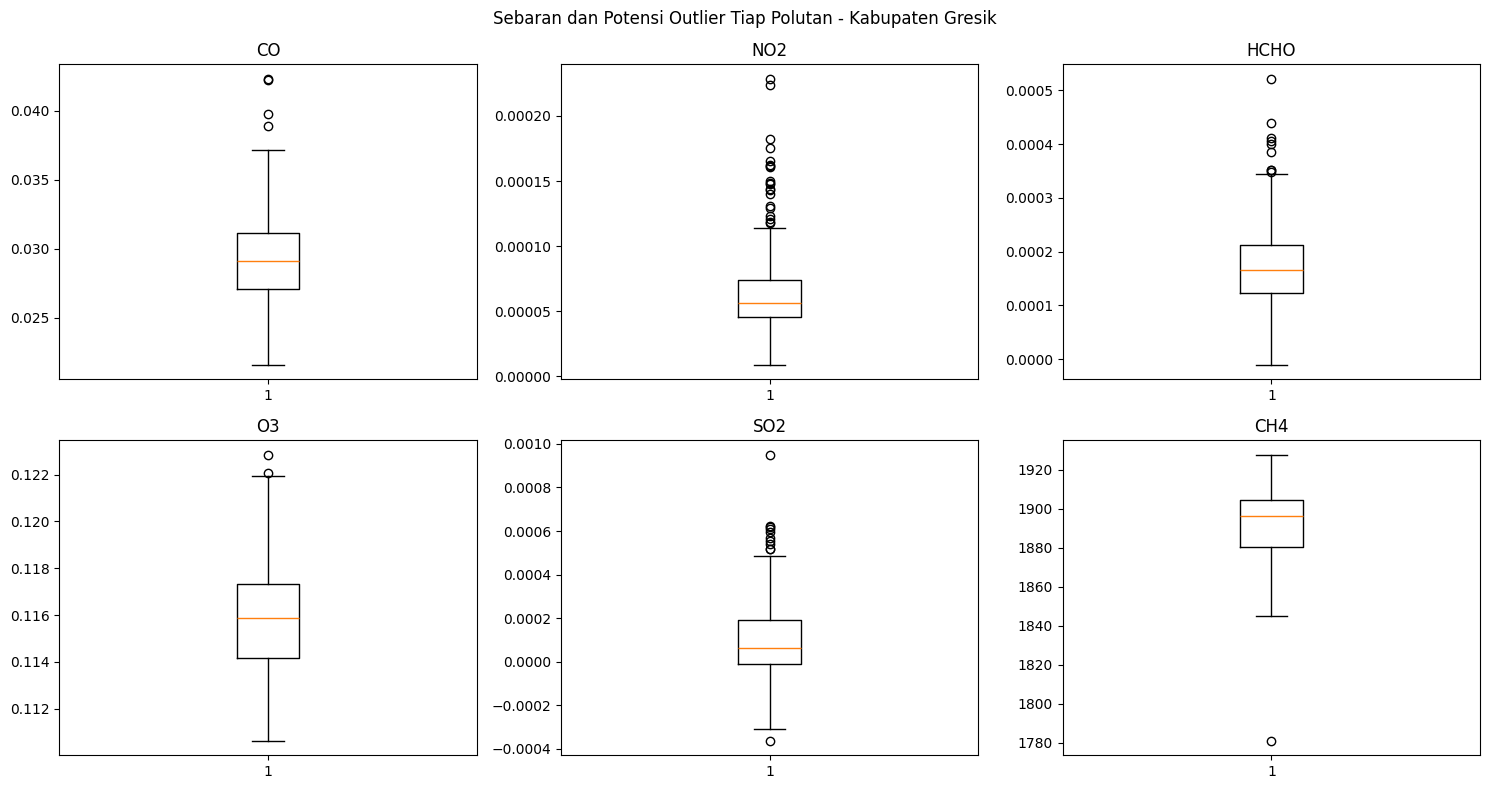

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, kode in zip(axes.flatten(), daftar_polutan):
    ax.boxplot(df[kode].dropna())
    ax.set_title(kode)

fig.suptitle("Sebaran dan Potensi Outlier Tiap Polutan - Kabupaten Gresik")
plt.tight_layout()
plt.show()

**Penjelasan kode:** `plt.subplots(2, 3, ...)` membuat 6 area gambar (2 baris × 3 kolom) sekaligus, satu untuk tiap polutan. Perulangan `zip(axes.flatten(), daftar_polutan)` memasangkan tiap area gambar dengan satu polutan, lalu `ax.boxplot(...)` menggambarkan sebaran nilainya — kotak menunjukkan rentang kuartil, garis tengah menunjukkan median, dan titik-titik di luar whisker menandakan kandidat outlier.

Beberapa nilai SO2 dan HCHO tercatat sedikit negatif. Secara fisis, konsentrasi gas tidak mungkin bernilai negatif — kondisi ini muncul karena *noise* pada proses retrieval satelit ketika konsentrasi sebenarnya sangat rendah/mendekati nol, dan cukup umum dijumpai pada data Sentinel-5P. Nilai tersebut tetap dipertahankan pada tahap ini, tidak diperlakukan sebagai kesalahan input.

### 2.7 Grafik Time Series

Dibuat dua jenis grafik: grafik gabungan yang telah dinormalisasi ke rentang 0–1 agar keenam polutan (dengan satuan dan skala berbeda) dapat dibandingkan pada satu sumbu, serta grafik terpisah per polutan dengan skala aslinya.

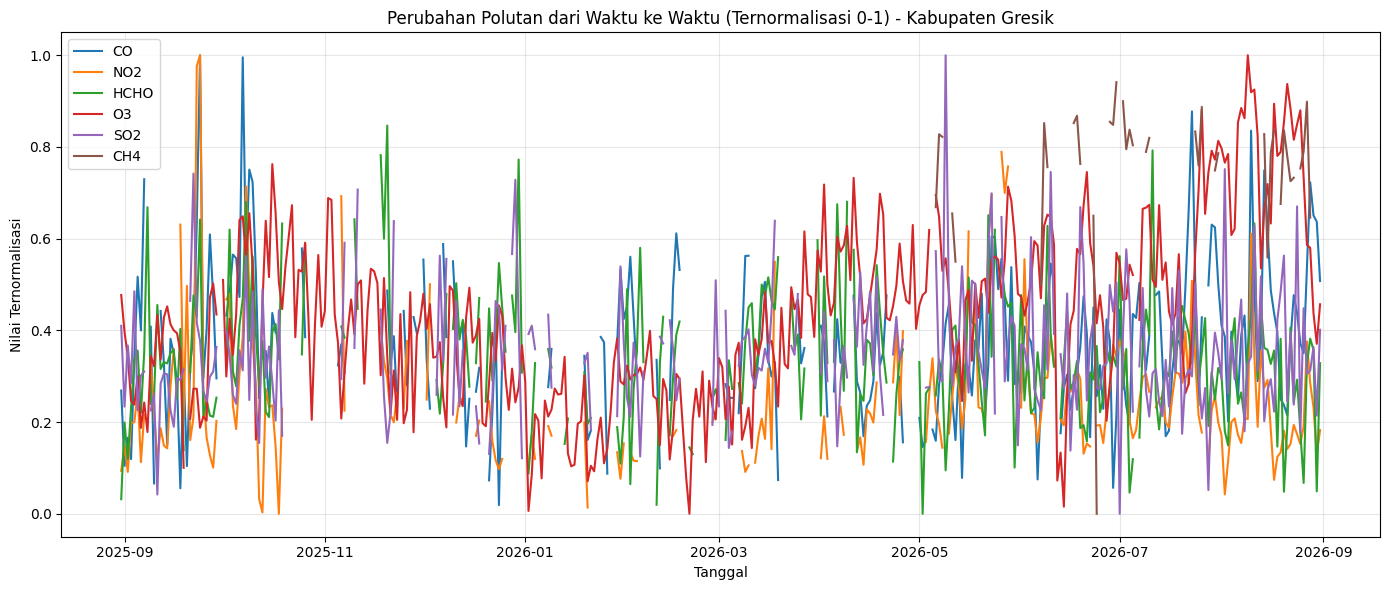

In [ ]:
df_norm = df[daftar_polutan].apply(lambda kolom: (kolom - kolom.min()) / (kolom.max() - kolom.min()))

plt.figure(figsize=(14, 6))
for kode in daftar_polutan:
    plt.plot(df["date"], df_norm[kode], label=kode)

plt.title("Perubahan Polutan dari Waktu ke Waktu (Ternormalisasi 0-1) - Kabupaten Gresik")
plt.xlabel("Tanggal")
plt.ylabel("Nilai Ternormalisasi")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Penjelasan kode:** `df[daftar_polutan].apply(lambda kolom: ...)` menerapkan normalisasi *min-max* ke tiap kolom polutan secara terpisah, sehingga seluruh nilai dipetakan ke rentang 0-1 berdasarkan nilai minimum dan maksimumnya masing-masing. Dengan skala yang seragam ini, keenam polutan — yang aslinya punya satuan dan rentang nilai sangat berbeda — bisa digambar dalam satu grafik garis yang sama untuk melihat pola kenaikan/penurunannya secara relatif.

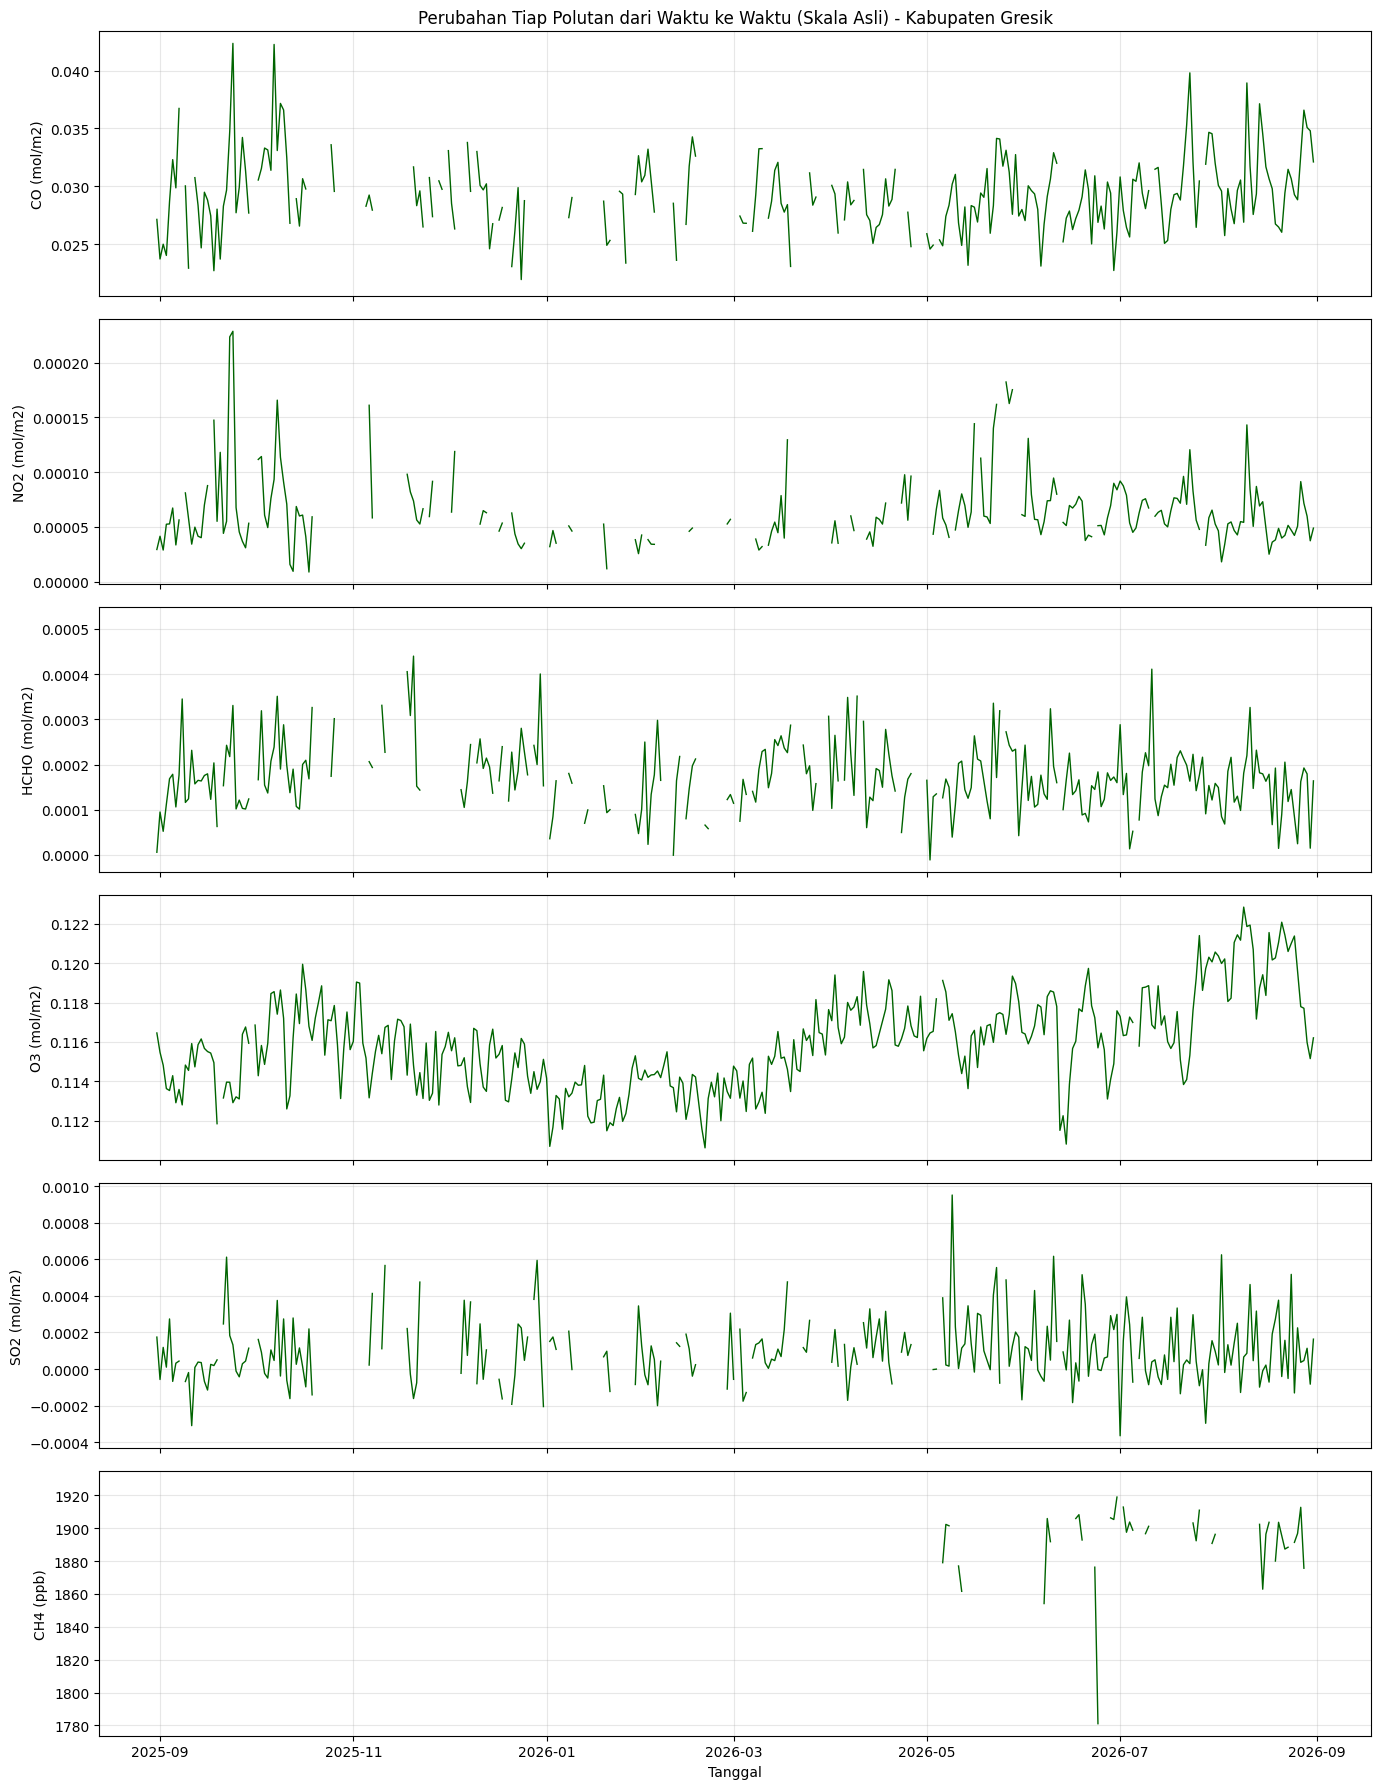

In [ ]:
fig, axes = plt.subplots(len(daftar_polutan), 1, figsize=(14, 3 * len(daftar_polutan)), sharex=True)

for ax, kode in zip(axes, daftar_polutan):
    ax.plot(df["date"], df[kode], linewidth=1, color="darkgreen")
    ax.set_ylabel(f"{kode} (ppb)" if kode == "CH4" else f"{kode} (mol/m2)")
    ax.grid(alpha=0.3)

axes[0].set_title("Perubahan Tiap Polutan dari Waktu ke Waktu (Skala Asli) - Kabupaten Gresik")
axes[-1].set_xlabel("Tanggal")
plt.tight_layout()
plt.show()

**Penjelasan kode:** Berbeda dari grafik sebelumnya, di sini dibuat satu area gambar tersendiri untuk tiap polutan (`plt.subplots(len(daftar_polutan), 1, ..., sharex=True)`) menggunakan nilai aslinya (tanpa normalisasi). Pendekatan ini dipakai agar polutan dengan rentang nilai sangat kecil (seperti NO2 atau SO2) maupun sangat besar (CH4) tetap terlihat jelas polanya, karena tidak "tenggelam" oleh skala polutan lain seperti yang berpotensi terjadi pada grafik gabungan.

### 2.8 Menyimpan Data CSV ke Database Aiven PostgreSQL

Data hasil crawling yang telah disimpan dalam file polutan_gresik_timeseries.csv selanjutnya dimasukkan ke database Aiven PostgreSQL menggunakan Google Colab. Proses ini dilakukan dengan membaca file CSV menggunakan Pandas, kemudian membuat koneksi ke database Aiven PostgreSQL menggunakan SQLAlchemy. Setelah koneksi berhasil, data dimasukkan ke dalam tabel

In [47]:
# membaca ulang CSV pollutant_data_gresik.csv, lalu mengunggahnya ke basis data PostgreSQL (Aiven)
import pandas as pd
from sqlalchemy import create_engine
from google.colab import userdata

df_baru = pd.read_csv("polutan_gresik_timeseries.csv")

AIVEN_USER     = userdata.get("AIVEN_USER")
AIVEN_PASSWORD = userdata.get("AIVEN_PASSWORD")
AIVEN_HOST     = userdata.get("AIVEN_HOST")
AIVEN_PORT     = userdata.get("AIVEN_PORT")
AIVEN_DB       = userdata.get("AIVEN_DB")

db_url = f"postgresql+psycopg2://{AIVEN_USER}:{AIVEN_PASSWORD}@{AIVEN_HOST}:{AIVEN_PORT}/{AIVEN_DB}?sslmode=require"
engine = create_engine(db_url)

df_baru.to_sql("Polutan_gresik", engine, if_exists="replace", index=False)

print(f"Berhasil! {len(df_baru)} baris terupload ke Aiven.")
print(pd.read_sql('SELECT * FROM "Polutan_gresik" LIMIT 5', engine))

Berhasil! 366 baris terupload ke Aiven.
         date        CO       NO2      HCHO        O3       SO2         CH4
0  2025-08-31  0.027154  0.000029  0.000006  0.116457  0.000175         NaN
1  2025-09-01  0.023740  0.000041  0.000095  0.115472 -0.000057         NaN
2  2025-09-02  0.025013  0.000029  0.000052  0.114820  0.000119  1864.20105
3  2025-09-03  0.024046  0.000052  0.000112  0.113629  0.000010         NaN
4  2025-09-04  0.028691  0.000053  0.000169  0.113531  0.000274         NaN


**Penjelasan kode:** pd.read_csv() membaca file polutan_gresik_timeseries.csv, kemudian userdata.get() mengambil informasi koneksi Aiven yang disimpan sebagai Secret di Google Colab. create_engine() membuat koneksi ke PostgreSQL Aiven, sedangkan to_sql() mengunggah data ke tabel Polutan_gresik. Setelah itu, pd.read_sql() digunakan untuk menampilkan lima data pertama dari tabel sebagai pengecekan bahwa data berhasil tersimpan.

### 2.9 Menghubungkan Database PostgreSQL Aiven dengan KNIME

Data yang telah disimpan pada database PostgreSQL Aiven selanjutnya diakses menggunakan KNIME untuk dilakukan proses pengolahan dan analisis. Pada tahap ini, KNIME dihubungkan dengan database Aiven, kemudian tabel Polutan_gresik dipilih dan datanya dibaca ke dalam workflow. Proses tersebut menggunakan beberapa node yang saling terhubung, yaitu PostgreSQL Connector, DB Table Selector, DB Reader, dan Statistics.

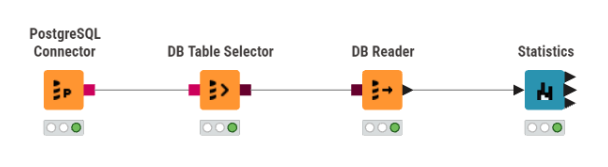

#### 1. PostgreSQL Connector

Node ini digunakan untuk menghubungkan KNIME dengan database PostgreSQL yang tersimpan di Aiven. Konfigurasi dilakukan dengan memasukkan hostname, port, nama database, username, dan password sesuai informasi koneksi Aiven.

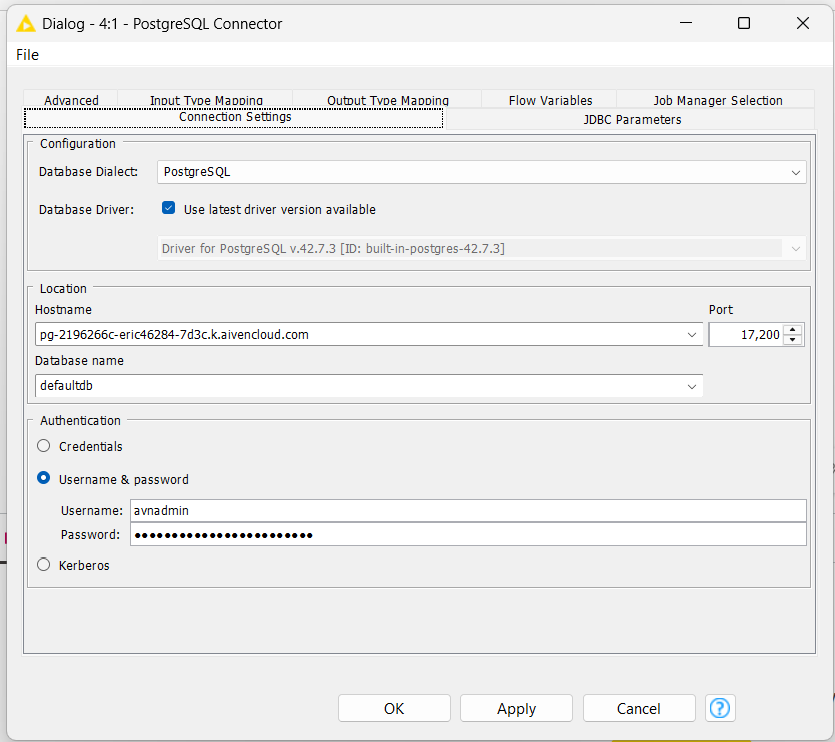

#### 2. DB Table Selector
Node ini digunakan untuk memilih tabel Polutan_gresik pada schema public yang akan digunakan dalam proses pengolahan data di KNIME.

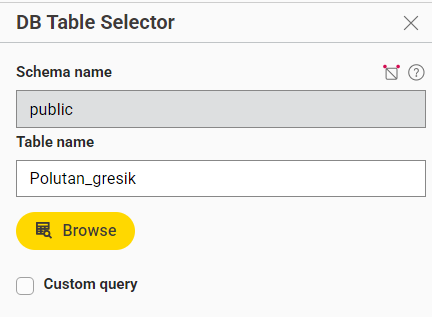

#### 3. DB Reader
Node ini digunakan untuk membaca dan mengambil data dari tabel Polutan_gresik yang telah dipilih sebelumnya, sehingga data dapat digunakan untuk proses analisis di KNIME.

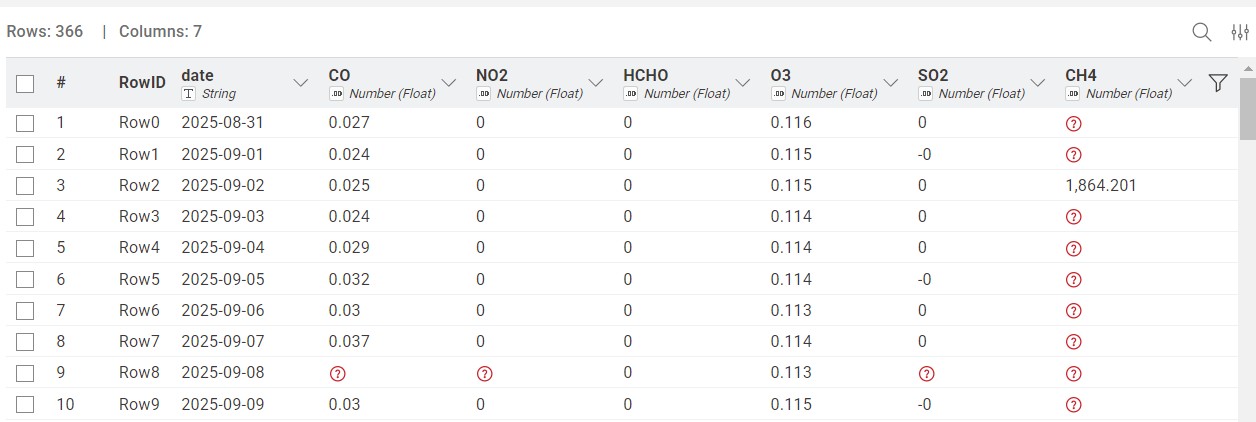

### 4. Statistics
Node ini digunakan untuk menganalisis data dari setiap polutan dan menghasilkan ringkasan statistik. Hasil analisis terdiri dari beberapa kolom, yaitu:

1. **Min** - menunjukkan nilai terendah yang terdapat pada setiap kolom polutan.
2. **Max** - menunjukkan nilai tertinggi yang terdapat pada setiap kolom polutan.
3. **Mean** - menunjukkan nilai rata-rata dari seluruh data pada kolom polutan.
4. **Std. deviation** - menunjukkan standar deviasi, yaitu ukuran penyebaran data dari nilai rata-ratanya.
5. **Variance** - menunjukkan varians, yaitu ukuran penyebaran data yang diperoleh dari kuadrat standar deviasi.
6. **Skewness** - menunjukkan tingkat kemiringan distribusi data. Nilai positif menunjukkan distribusi cenderung miring ke kanan, sedangkan nilai negatif menunjukkan kecenderungan miring ke kiri.
7. **Kurtosis** - menunjukkan tingkat keruncingan atau bentuk distribusi data dibandingkan dengan distribusi normal.
8. **Overall sum** - menunjukkan jumlah keseluruhan nilai pada setiap kolom polutan.
9. **No. missing** - menunjukkan jumlah data yang kosong atau *missing* pada setiap kolom.
10. **No. NaNs** - menunjukkan jumlah data yang bernilai NaN (*Not a Number*) pada setiap kolom.
11. **No. +oos** - menunjukkan jumlah data yang memiliki nilai positif tak hingga (+oo).
12. **No. -oos** - menunjukkan jumlah data yang memiliki nilai negatif tak hingga (-oo).
13. **Median** - menunjukkan nilai tengah dari seluruh data setelah data diurutkan.
14. **Row count** - menunjukkan jumlah baris data yang dianalisis. Pada hasil tersebut terdapat 366 baris untuk setiap polutan.
15. **Histogram** - menampilkan distribusi nilai data dalam bentuk grafik histogram sehingga dapat dilihat pola penyebaran nilai pada setiap polutan.

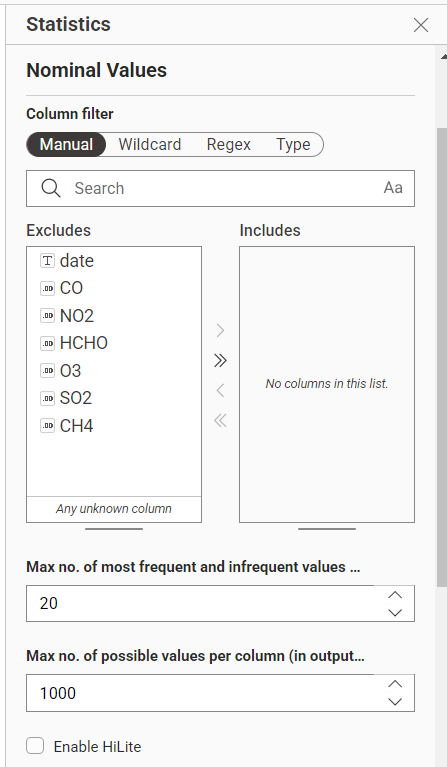

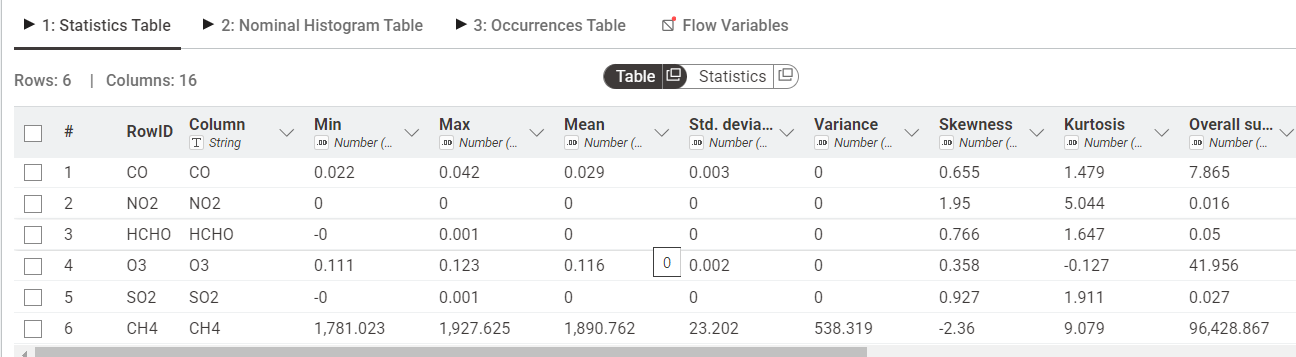

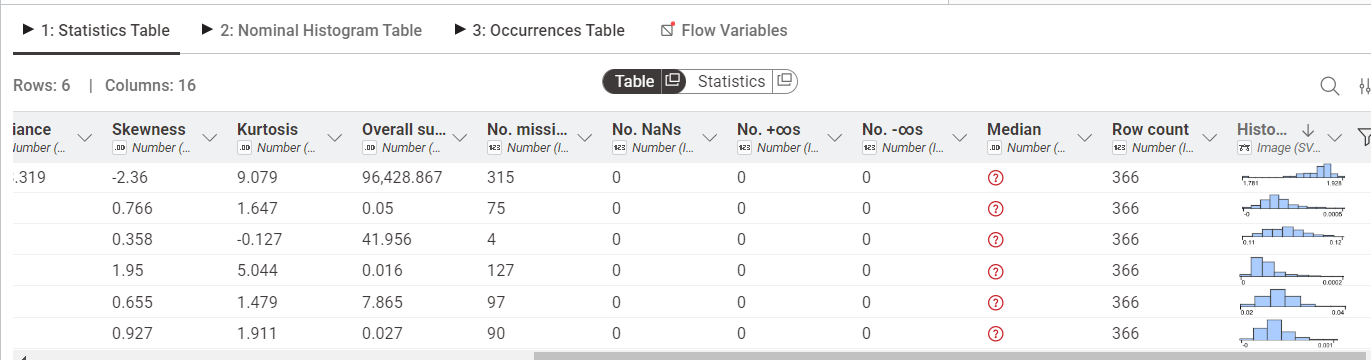

### 2.10 Contoh Perhitungan Statistics Manual

Sebagai contoh, perhitungan dilakukan menggunakan 5 data polutan **CO**, yaitu **0,027; 0,024; 0,025; 0,024; dan 0,029**.

#### **1. Min**

Nilai minimum merupakan nilai terkecil dari seluruh data.

$$
\text{Min} = \min(x)
$$

$$
\text{Min} = 0,024
$$

**Hasil: Min = 0,024**

#### **2. Max**

Nilai maksimum merupakan nilai terbesar dari seluruh data.

$$
\text{Max} = \max(x)
$$

$$
\text{Max} = 0,029
$$

**Hasil: Max = 0,029**

#### **3. Mean**

Mean merupakan nilai rata-rata dari seluruh data.

$$
\bar{x} = \frac{\sum x}{n}
$$

$$
\bar{x} =
\frac{0,027+0,024+0,025+0,024+0,029}{5}
= 0,0258
$$

**Hasil: Mean = 0,0258**

#### **4. Std. Deviation**

Standar deviasi menunjukkan tingkat penyebaran data terhadap nilai rata-rata.

$$
s = \sqrt{\frac{\sum(x-\bar{x})^2}{n}}
$$

$$
s = \sqrt{0,00000376}
\approx 0,00194
$$

**Hasil: Std. Deviation ≈ 0,00194**

#### **5. Variance**

Variance merupakan ukuran penyebaran data yang diperoleh dari kuadrat standar deviasi.

$$
s^2 = \frac{\sum(x-\bar{x})^2}{n}
$$

$$
s^2 = 0,00000376
$$

**Hasil: Variance = 0,00000376**

#### **6. Skewness**

Skewness menunjukkan tingkat kemiringan distribusi data terhadap nilai rata-ratanya.

$$
\text{Skewness}
=
\frac{1}{n}
\sum
\left(\frac{x-\bar{x}}{s}\right)^3
$$

Hasil perhitungan menunjukkan nilai skewness berdasarkan distribusi kelima data tersebut.

#### **7. Kurtosis**

Kurtosis menunjukkan tingkat keruncingan atau bentuk distribusi data.

$$
\text{Kurtosis}
=
\frac{1}{n}
\sum
\left(\frac{x-\bar{x}}{s}\right)^4
-3
$$

Nilai kurtosis menunjukkan karakteristik distribusi data dibandingkan dengan distribusi normal.

#### **8. Overall Sum**

Overall sum merupakan jumlah seluruh nilai data.

$$
\sum x
=
0,027+0,024+0,025+0,024+0,029
$$

$$
\sum x = 0,129
$$

**Hasil: Overall Sum = 0,129**

#### **9. No. Missing**

No. missing menunjukkan jumlah data yang kosong atau tidak memiliki nilai.

Pada contoh terdapat 5 data dan semuanya memiliki nilai.

$$
\text{No. Missing} = 0
$$

**Hasil: No. Missing = 0**

#### **10. No. NaNs**

No. NaNs menunjukkan jumlah data yang memiliki nilai **NaN (Not a Number)**.

Pada contoh tidak terdapat nilai NaN.

$$
\text{No. NaNs} = 0
$$

**Hasil: No. NaNs = 0**

#### **11. No. +∞s**

No. +∞s menunjukkan jumlah data yang memiliki nilai positif tak hingga (+∞).

Pada contoh tidak terdapat nilai +∞.

$$
\text{No. +∞s} = 0
$$

**Hasil: No. +∞s = 0**

#### **12. No. -∞s**

No. -∞s menunjukkan jumlah data yang memiliki nilai negatif tak hingga (-∞).

Pada contoh tidak terdapat nilai -∞.

$$
\text{No. -∞s} = 0
$$

**Hasil: No. -∞s = 0**

#### **13. Median**

Median merupakan nilai tengah setelah data diurutkan.

Data setelah diurutkan:

$$
0,024;\ 0,024;\ \mathbf{0,025};\ 0,027;\ 0,029
$$

$$
\text{Median} = 0,025
$$

**Hasil: Median = 0,025**

#### **14. Row Count**

Row count menunjukkan jumlah baris atau jumlah data yang dianalisis.

$$
\text{Row Count} = n = 5
$$

**Hasil: Row Count = 5**
